# 03 · Uplift Modeling

An A/B test gives the **average** treatment effect. But marketing budget is
finite — we want to e-mail the customers whose behaviour *changes because of*
the e-mail (the **persuadables**), not those who would have bought anyway
(sure-things) or those the e-mail puts off (sleeping-dogs).

Uplift modeling estimates the individual treatment effect

$$\tau(x) = P(\text{visit} \mid x, \text{treated}) - P(\text{visit} \mid x, \text{control})$$

We compare two meta-learners — **S-learner** and **T-learner** — implemented
from scratch, and evaluate them with the **Qini curve**, the uplift analogue of
the ROC curve.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
FIG = Path.cwd().parent / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from src.data.load import load_raw, full_treatment_flag
from src.data.features import build_features
from src.uplift.learners import SLearner, TLearner, qini_curve, qini_coefficient, uplift_at_k
from src.evaluation.plots import plot_qini, plot_uplift_by_bin

df = full_treatment_flag(load_raw())   # treatment = any e-mail vs none
X = build_features(df)
y = df["visit"].values
t = df["treatment"].values
X_tr, X_te, y_tr, y_te, t_tr, t_te = train_test_split(
    X, y, t, test_size=0.3, random_state=42, stratify=t
)
X_tr.shape, X_te.shape

((44800, 15), (19200, 15))

## Fit both meta-learners
Base model is LightGBM for both, so the comparison is fair.

In [3]:
base = LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31,
                      subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
s_learner = SLearner(base).fit(X_tr, t_tr, y_tr)
t_learner = TLearner(base).fit(X_tr, t_tr, y_tr)
up_s = s_learner.predict_uplift(X_te)
up_t = t_learner.predict_uplift(X_te)
print(f"S-learner uplift: mean={up_s.mean():+.4f}  sd={up_s.std():.4f}")
print(f"T-learner uplift: mean={up_t.mean():+.4f}  sd={up_t.std():.4f}")

S-learner uplift: mean=+0.0624  sd=0.0344
T-learner uplift: mean=+0.0643  sd=0.0596


## Qini curves
How much incremental visit we capture by targeting the top-ranked customers.

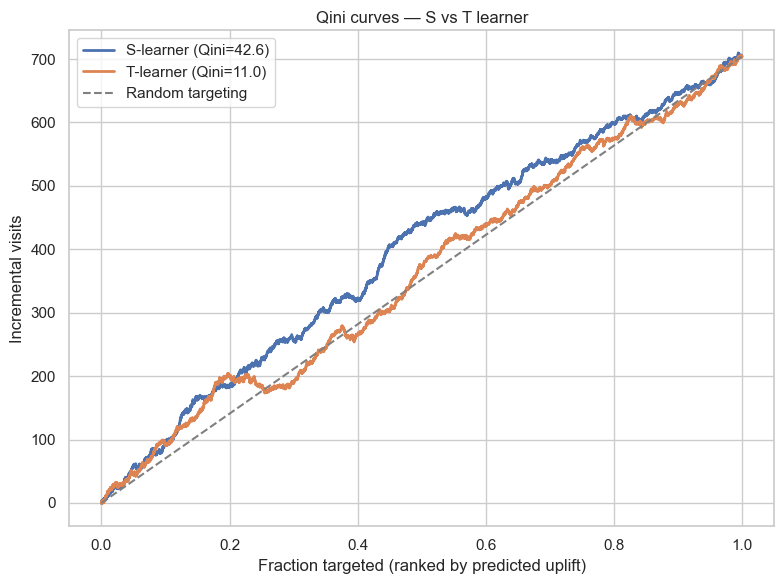

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
for up, name in [(up_s, "S-learner"), (up_t, "T-learner")]:
    f, q = qini_curve(up, t_te, y_te)
    ax.plot(f, q, linewidth=2, label=f"{name} (Qini={qini_coefficient(up, t_te, y_te):.1f})")
ax.plot([0, 1], [0, q[-1]], "--", color="grey", label="Random targeting")
ax.set_xlabel("Fraction targeted (ranked by predicted uplift)")
ax.set_ylabel("Incremental visits"); ax.set_title("Qini curves — S vs T learner"); ax.legend()
plt.tight_layout(); plt.savefig(FIG / "03_qini_curves.png", dpi=120, bbox_inches="tight"); plt.show()

## Uplift by decile (best learner)
Green = persuadable, red = negative uplift (sleeping dogs).

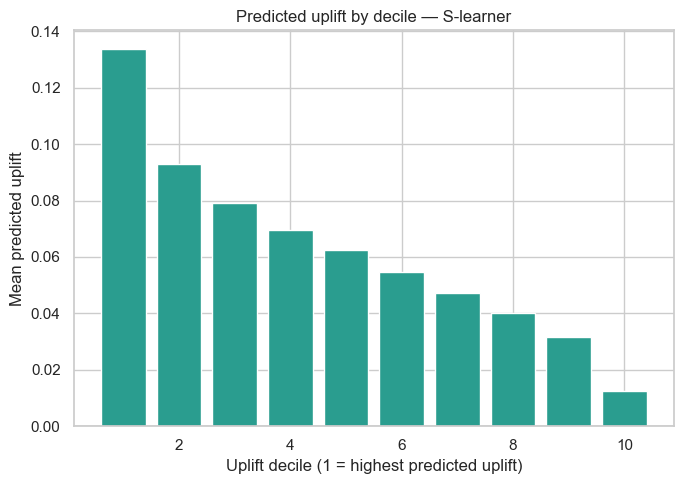

In [5]:
best_up = up_s if qini_coefficient(up_s, t_te, y_te) >= qini_coefficient(up_t, t_te, y_te) else up_t
best_name = "S-learner" if best_up is up_s else "T-learner"
ax = plot_uplift_by_bin(best_up, n_bins=10)
ax.set_title(f"Predicted uplift by decile — {best_name}")
plt.tight_layout(); plt.savefig(FIG / "03_uplift_deciles.png", dpi=120, bbox_inches="tight"); plt.show()

## Observed incremental response at the top-k targeted

In [6]:
rows = []
for k in [0.1, 0.2, 0.3, 0.5, 1.0]:
    r = uplift_at_k(best_up, t_te, y_te, k)
    rows.append(r)
uplift_table = pd.DataFrame(rows)
uplift_table

,k,n_targeted,response_treated,response_control,incremental_rate
0,0.1000,1920,0.2273,0.1553,0.0720
1,0.2000,3840,0.2161,0.1442,0.0719
2,0.3000,5760,0.2038,0.1379,0.0658
3,0.5000,9600,0.1890,0.1206,0.0684
4,1.0000,19200,0.1651,0.1101,0.0550


## Takeaways

- The **S-learner clearly beats the T-learner** here. The T-learner differences
  two separately-trained models, and on a ~15% base-rate binary outcome that
  noise dominates — its Qini curve even dips *below* random targeting in the
  middle of the ranking. The S-learner, sharing one model with treatment as a
  feature, is far more stable.
- Observed incremental visit rate in the **top decile** is well above the
  population average treatment effect — the model concentrates the persuadables.
- The decile plot shows a genuinely negative-uplift tail: customers we should
  **not** e-mail. Notebook 04 turns this ranking into a budget policy.